# **Results Comparison**
In this section, the performance of the two approaches (MLP with NASnet and VotingClassifier with Xception feature extraction) is compared using several evaluation metrics, including accuracy, precision, recall, and F1-score. To perform this comparison, the metrics obtained during the experiments were stored in a JSON file, which allows the results to be saved and reused without recomputing the models.

The JSON file containing the metrics for both approaches is then loaded and used to generate visualizations such as bar charts and radar plots. These visualizations help to clearly compare the performance of the models across different evaluation metrics and provide a more intuitive understanding of the differences between the two approaches.

In [22]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **Load json Results**

In [23]:

BASE_DIR = "results"

with open(os.path.join(BASE_DIR, "evaluation_results_baseline.json")) as f:
    baseline = json.load(f)

with open(os.path.join(BASE_DIR, "evaluation_results_optuna.json")) as f:
    optuna = json.load(f)



In [24]:
metrics = [
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "auc",
    "inference_time_ms"
]

#improvement direction for each metric
maximize_metrics = {
    "accuracy": True,
    "precision": True,
    "recall": True,
    "f1_score": True,
    "auc": True,
    "inference_time_ms": False
}

# **Build Comparison Table**

In [25]:
rows = []

for metric in metrics:

    baseline_value = baseline[metric]
    optuna_value = optuna[metric]

    # Percentage improvement
    if maximize_metrics[metric]:

        percent_change = (
            (optuna_value - baseline_value)
            / baseline_value
        ) * 100

        improved = optuna_value > baseline_value

    else:

        percent_change = (
            (baseline_value - optuna_value)
            / baseline_value
        ) * 100

        improved = optuna_value < baseline_value

    rows.append({
        "Metric": metric,
        "Baseline": baseline_value,
        "Optuna": optuna_value,
        "Improvement (%)": percent_change,
        "Better Model": "Optuna" if improved else "Baseline"
    })


comparison_df = pd.DataFrame(rows)


comparison_df["Baseline"] = comparison_df["Baseline"].map(
    lambda x: f"{x:.6f}"
)

comparison_df["Optuna"] = comparison_df["Optuna"].map(
    lambda x: f"{x:.6f}"
)

comparison_df["Improvement (%)"] = comparison_df[
    "Improvement (%)"
].map(lambda x: f"{x:.4f}%")


In [26]:
print(comparison_df)

output_path = os.path.join(
    BASE_DIR,
    "metrics_comparison.csv"
)

comparison_df.to_csv(
    output_path,
    index=False
)

print(f"\nComparison exported to: {output_path}")  

              Metric   Baseline     Optuna Improvement (%) Better Model
0           accuracy   0.998996   0.999205         0.0209%       Optuna
1          precision   0.999997   0.999998         0.0001%       Optuna
2             recall   0.998997   0.999205         0.0208%       Optuna
3           f1_score   0.999497   0.999601         0.0105%       Optuna
4                auc   0.999717   0.999730         0.0013%       Optuna
5  inference_time_ms  65.179021  59.301979         9.0168%       Optuna

Comparison exported to: results\metrics_comparison.csv


In [27]:
df = comparison_df.copy()

In [28]:
df.head(10)

,Metric,Baseline,Optuna,Improvement (%),Better Model
0,accuracy,0.998996,0.999205,0.0209%,Optuna
1,precision,0.999997,0.999998,0.0001%,Optuna
2,recall,0.998997,0.999205,0.0208%,Optuna
3,f1_score,0.999497,0.999601,0.0105%,Optuna
4,auc,0.999717,0.999730,0.0013%,Optuna
5,inference_time_ms,65.179021,59.301979,9.0168%,Optuna


# **Overall Average Performance per Configuration**

Plot saved to:
- results\plots\average_classification_performance.png
- results\plots\average_classification_performance.pdf


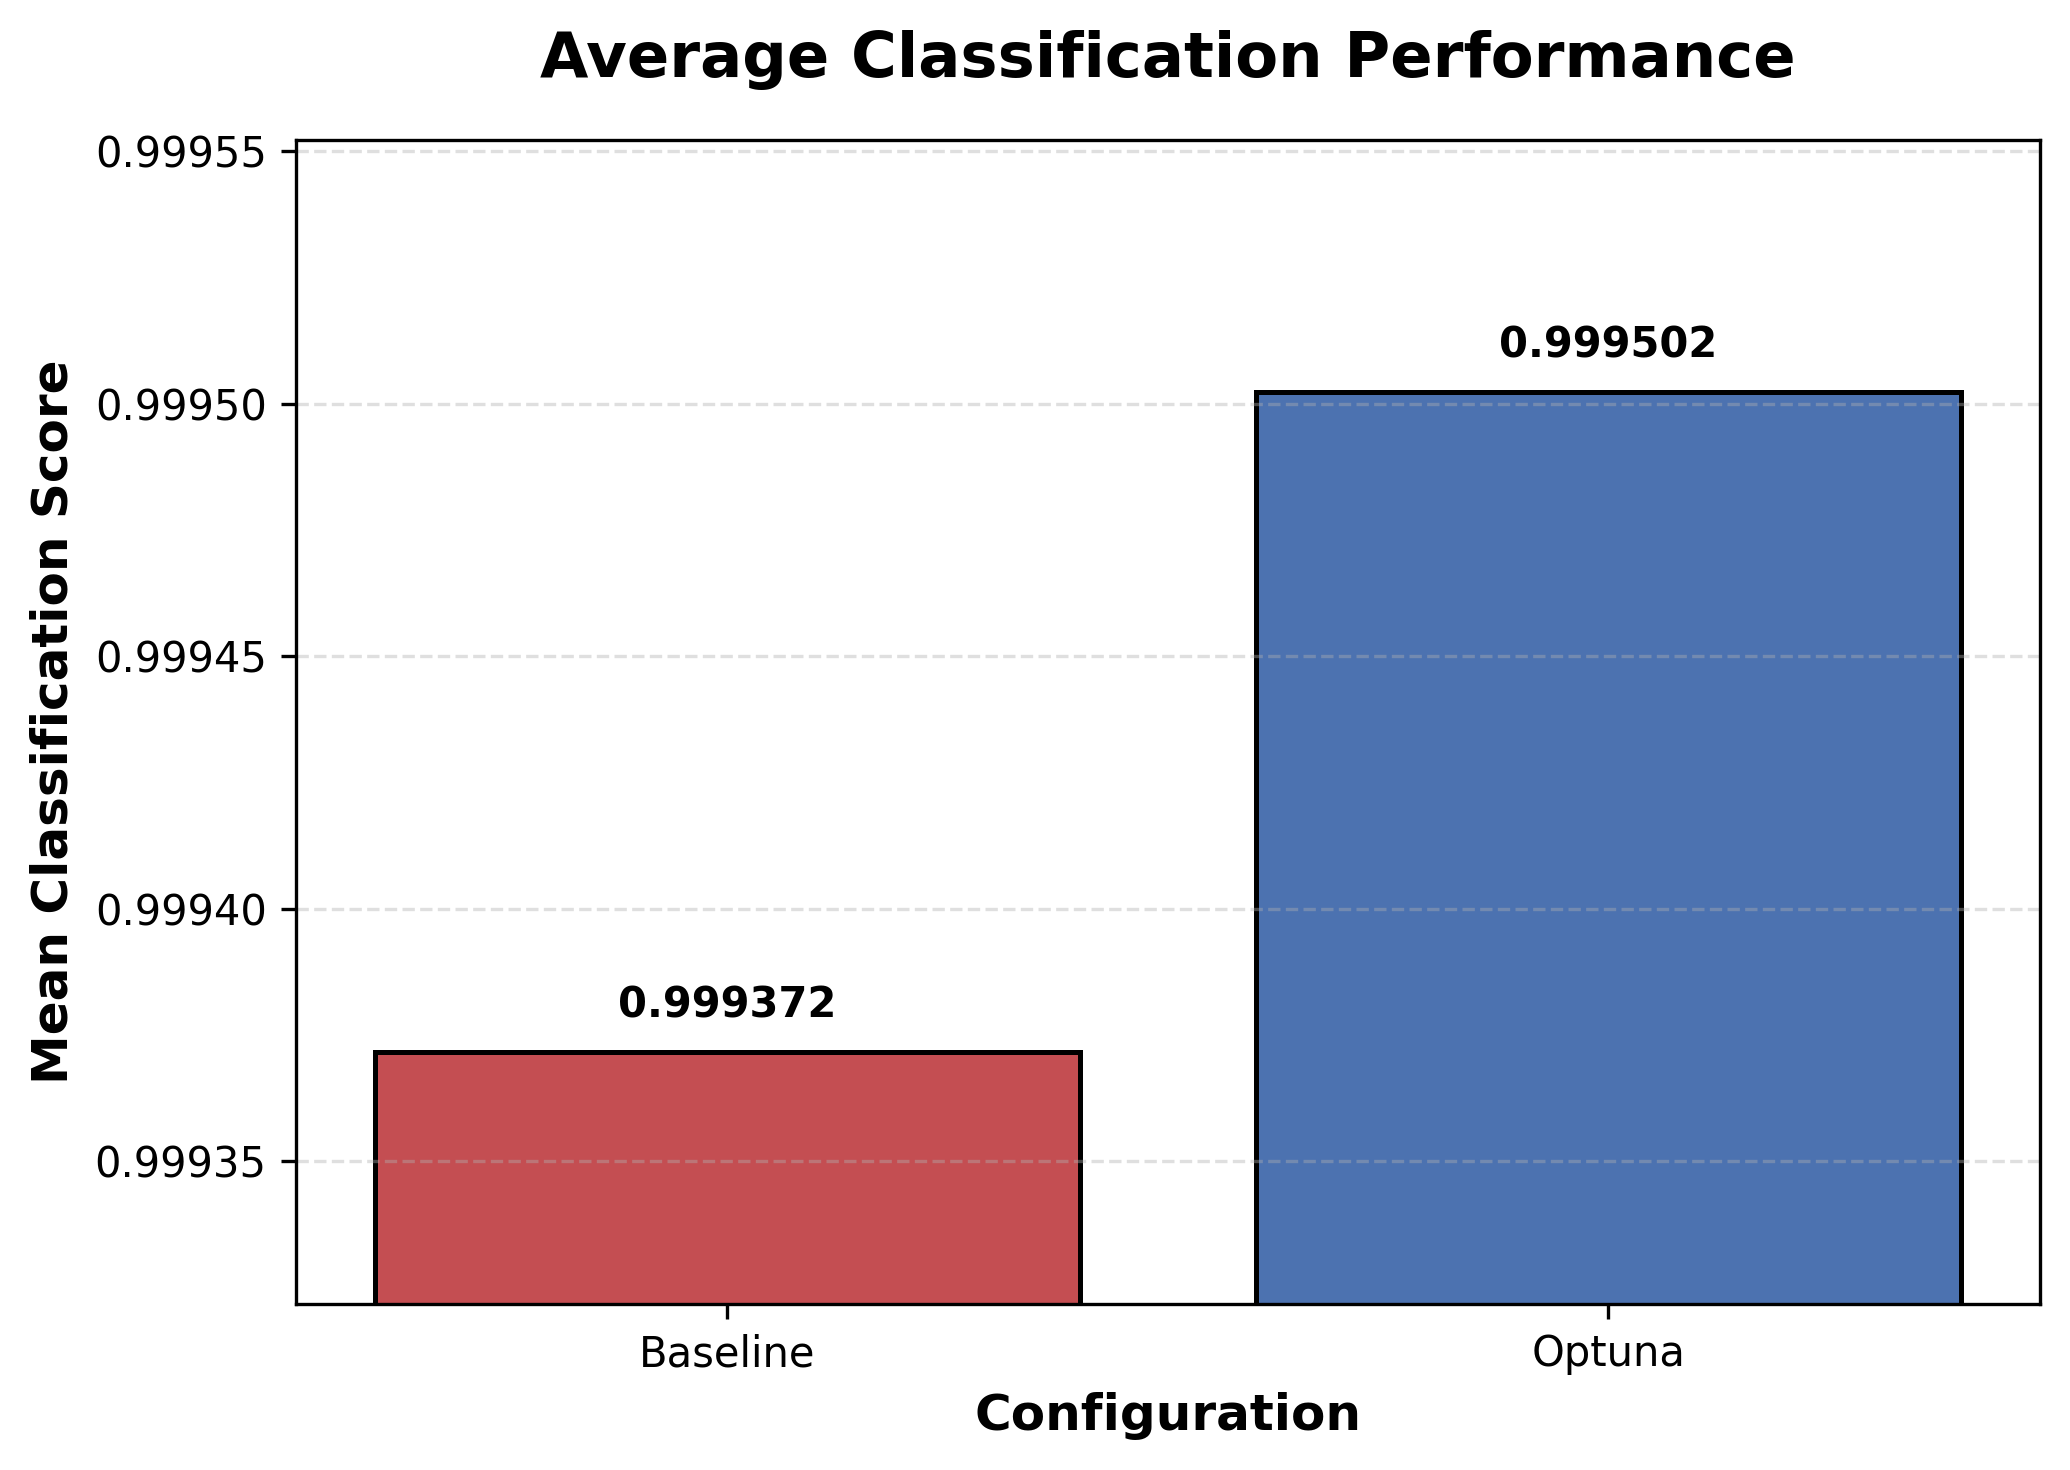

In [29]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# =========================================================
# Use ONLY classification metrics
# =========================================================

classification_metrics = [
    "accuracy",
    "precision",
    "recall",
    "f1_score"
]

# Filter dataframe
score_df = df[
    df["Metric"].isin(classification_metrics)
].copy()


# =========================================================
# Create comparison dataframe
# =========================================================

plot_df = pd.DataFrame({
    "configuration": ["Baseline", "Optuna"],
    "mean_score": [
        score_df["Baseline"].astype(float).mean(),
        score_df["Optuna"].astype(float).mean()
    ]
})


# =========================================================
# Identify best/worst
# =========================================================

max_value = plot_df["mean_score"].max()
min_value = plot_df["mean_score"].min()

colors = []

for value in plot_df["mean_score"]:

    if value == max_value:
        colors.append("#4C72B0")   # Best

    elif value == min_value:
        colors.append("#C44E52")   # Worst

    else:
        colors.append("#DDDDDD")


# =========================================================
# Create plot
# =========================================================

plt.figure(figsize=(7, 5), dpi=300)

bars = plt.bar(
    plot_df["configuration"],
    plot_df["mean_score"],
    color=colors,
    edgecolor="black",
    linewidth=1.2
)


# =========================================================
# Labels
# =========================================================

plt.title(
    "Average Classification Performance",
    fontsize=15,
    weight="bold",
    pad=15
)

plt.ylabel(
    "Mean Classification Score",
    fontsize=12,
    weight="bold"
)

plt.xlabel(
    "Configuration",
    fontsize=12,
    weight="bold"
)


# =========================================================
# Dynamic limits
# =========================================================

margin = 0.00005

plt.ylim(
    plot_df["mean_score"].min() - margin,
    plot_df["mean_score"].max() + margin
)


# =========================================================
# Grid
# =========================================================

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)


# =========================================================
# Annotate bars
# =========================================================

for bar in bars:

    yval = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.000005,
        f"{yval:.6f}",
        ha="center",
        va="bottom",
        fontsize=10,
        weight="bold"
    )


# =========================================================
# Save figure
# =========================================================

save_dir = os.path.join("results", "plots")
os.makedirs(save_dir, exist_ok=True)

png_path = os.path.join(
    save_dir,
    "average_classification_performance.png"
)

pdf_path = os.path.join(
    save_dir,
    "average_classification_performance.pdf"
)

plt.tight_layout()

plt.savefig(
    png_path,
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    pdf_path,
    bbox_inches="tight"
)

print(f"Plot saved to:\n- {png_path}\n- {pdf_path}")

plt.show()

Plot saved to:
- results\plots\baseline_vs_optuna_comparison.png
- results\plots\baseline_vs_optuna_comparison.pdf


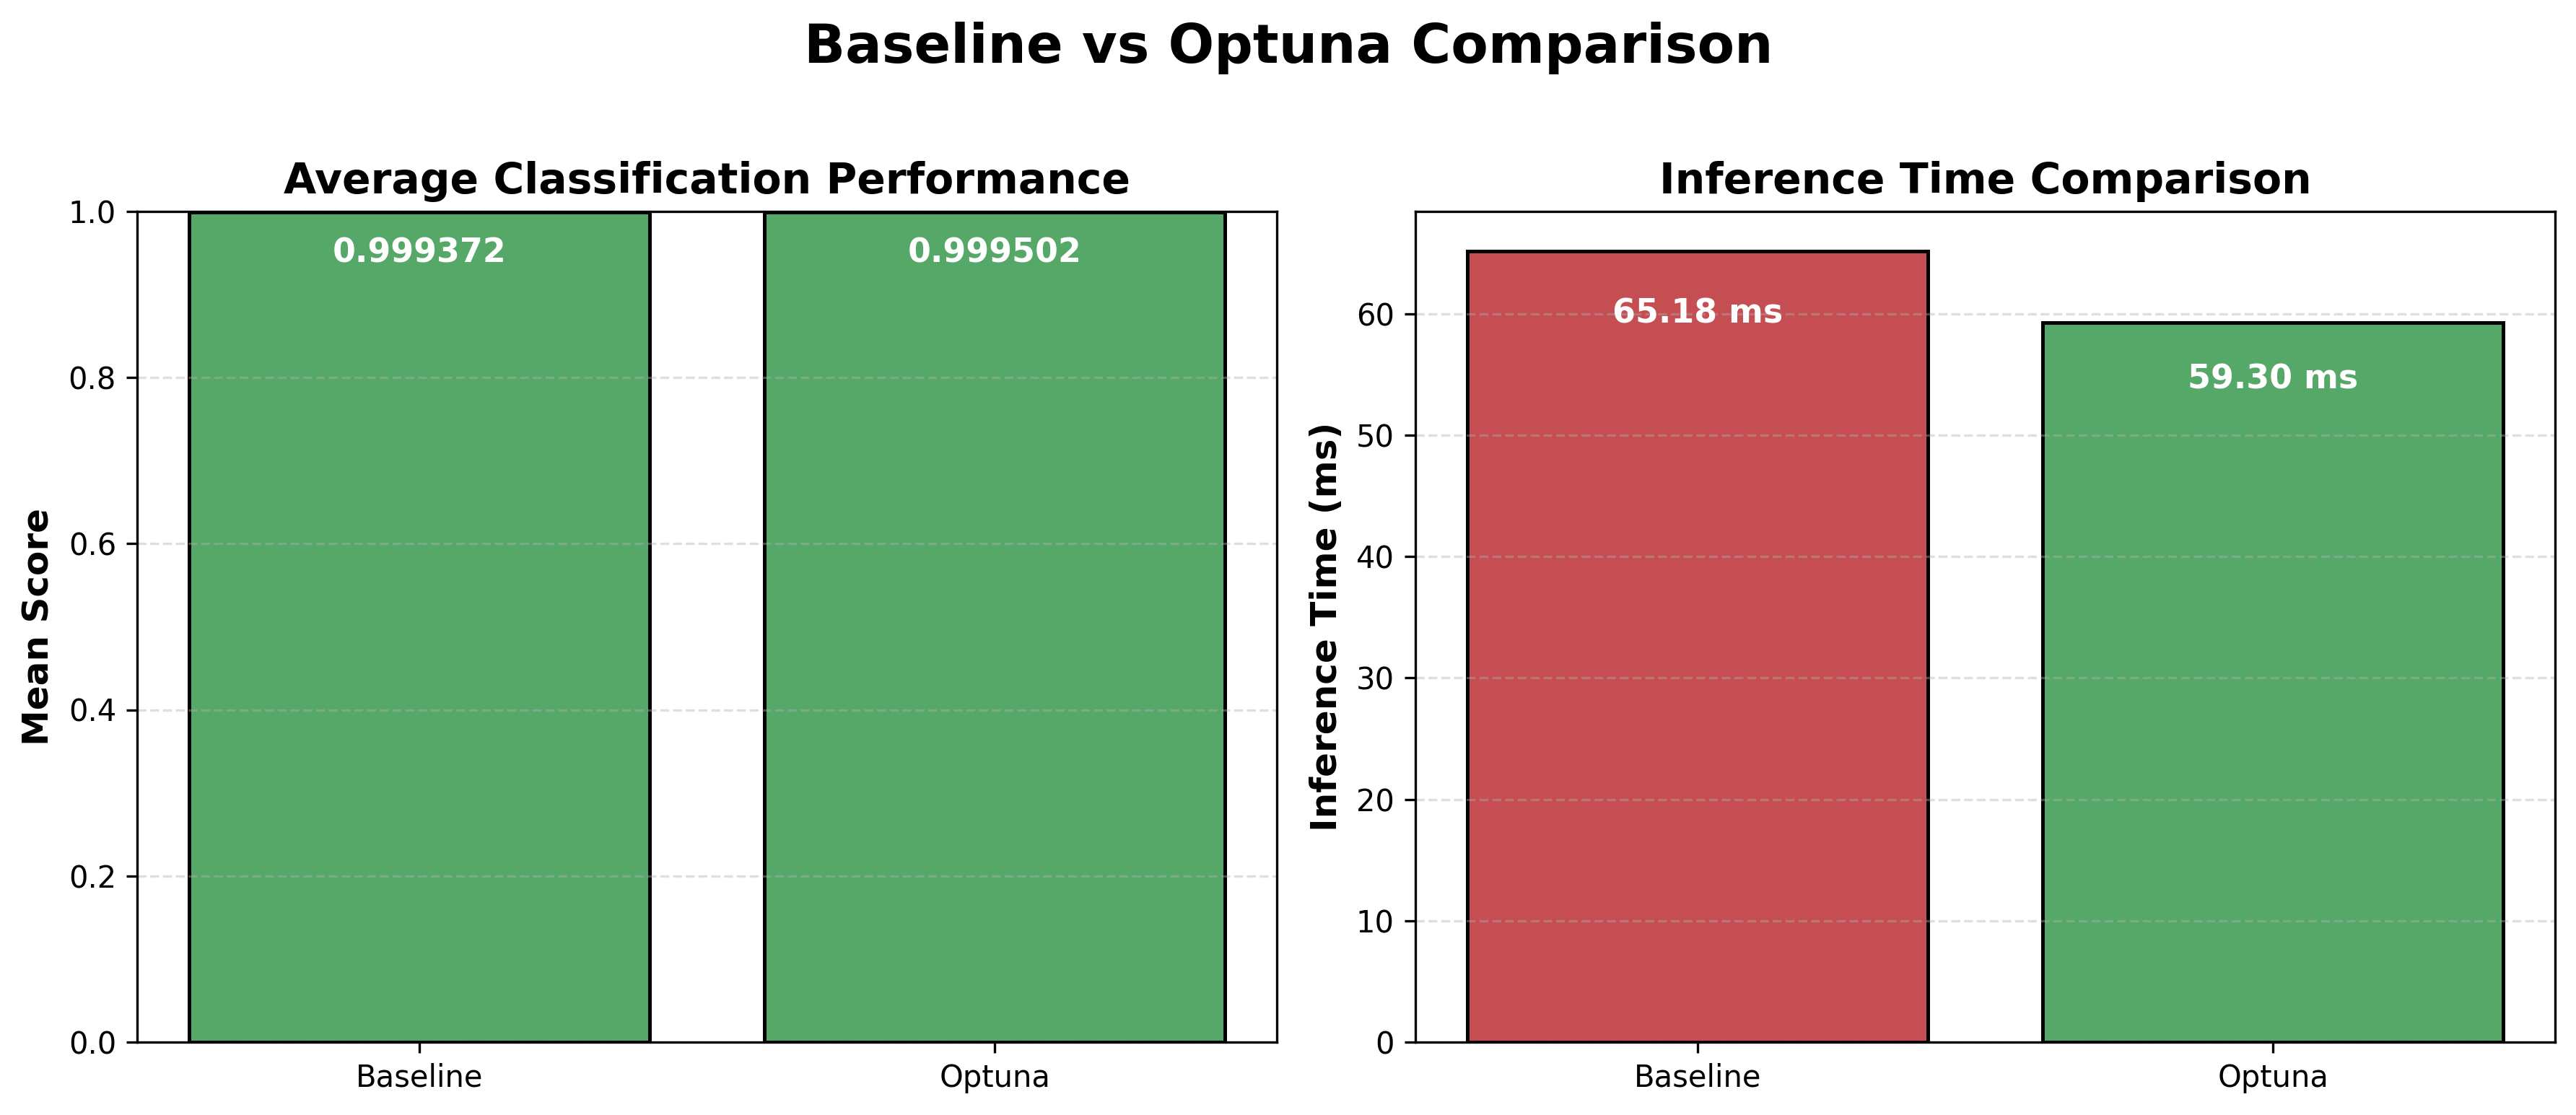

In [30]:
import os
import matplotlib.pyplot as plt
import pandas as pd


# =========================================================
# Classification Metrics
# =========================================================

classification_metrics = [
    "accuracy",
    "precision",
    "recall",
    "f1_score"
]


# =========================================================
# Compute Mean Classification Performance
# =========================================================

score_df = df[
    df["Metric"].isin(classification_metrics)
].copy()

baseline_mean = score_df["Baseline"].astype(float).mean()
optuna_mean = score_df["Optuna"].astype(float).mean()


# =========================================================
# Extract Inference Time
# =========================================================

baseline_time = float(
    df[df["Metric"] == "inference_time_ms"]["Baseline"].values[0]
)

optuna_time = float(
    df[df["Metric"] == "inference_time_ms"]["Optuna"].values[0]
)


# =========================================================
# Create Figure
# =========================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5),
    dpi=300
)


# =========================================================
# LEFT PLOT — Classification Performance
# =========================================================

performance_values = [baseline_mean, optuna_mean]
performance_labels = ["Baseline", "Optuna"]

bars1 = axes[0].bar(
    performance_labels,
    performance_values,
    color=["#55A868", "#55A868"],   # both green
    edgecolor="black",
    linewidth=1.2
)

axes[0].set_ylim(0.0, 1.0)

axes[0].set_title(
    "Average Classification Performance",
    fontsize=14,
    weight="bold"
)

axes[0].set_ylabel(
    "Mean Score",
    fontsize=12,
    weight="bold"
)

axes[0].grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)


# =========================================================
# Labels INSIDE bars
# =========================================================

for bar in bars1:

    yval = bar.get_height()

    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        yval - 0.05,
        f"{yval:.6f}",
        ha="center",
        va="center",
        fontsize=11,
        weight="bold",
        color="white"
    )


# =========================================================
# RIGHT PLOT — Inference Time
# =========================================================

time_values = [baseline_time, optuna_time]
time_labels = ["Baseline", "Optuna"]

# Higher time = red
# Lower time = green

time_colors = []

max_time = max(time_values)

for value in time_values:

    if value == max_time:
        time_colors.append("#C44E52")   # slower -> red
    else:
        time_colors.append("#55A868")   # faster -> green


bars2 = axes[1].bar(
    time_labels,
    time_values,
    color=time_colors,
    edgecolor="black",
    linewidth=1.2
)

axes[1].set_title(
    "Inference Time Comparison",
    fontsize=14,
    weight="bold"
)

axes[1].set_ylabel(
    "Inference Time (ms)",
    fontsize=12,
    weight="bold"
)

axes[1].grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)


# =========================================================
# Labels INSIDE inference bars
# =========================================================

for bar in bars2:

    yval = bar.get_height()

    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        yval - (yval * 0.08),
        f"{yval:.2f} ms",
        ha="center",
        va="center",
        fontsize=11,
        weight="bold",
        color="white"
    )


# =========================================================
# Global Formatting
# =========================================================

plt.suptitle(
    "Baseline vs Optuna Comparison",
    fontsize=18,
    weight="bold",
    y=1.02
)

plt.tight_layout()


# =========================================================
# Save Figure
# =========================================================

save_dir = os.path.join("results", "plots")
os.makedirs(save_dir, exist_ok=True)

png_path = os.path.join(
    save_dir,
    "baseline_vs_optuna_comparison.png"
)

pdf_path = os.path.join(
    save_dir,
    "baseline_vs_optuna_comparison.pdf"
)

plt.savefig(
    png_path,
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    pdf_path,
    bbox_inches="tight"
)

print(f"Plot saved to:\n- {png_path}\n- {pdf_path}")

plt.show()

Plot saved to:
- results\plots\combined_metric_comparison.png
- results\plots\combined_metric_comparison.pdf


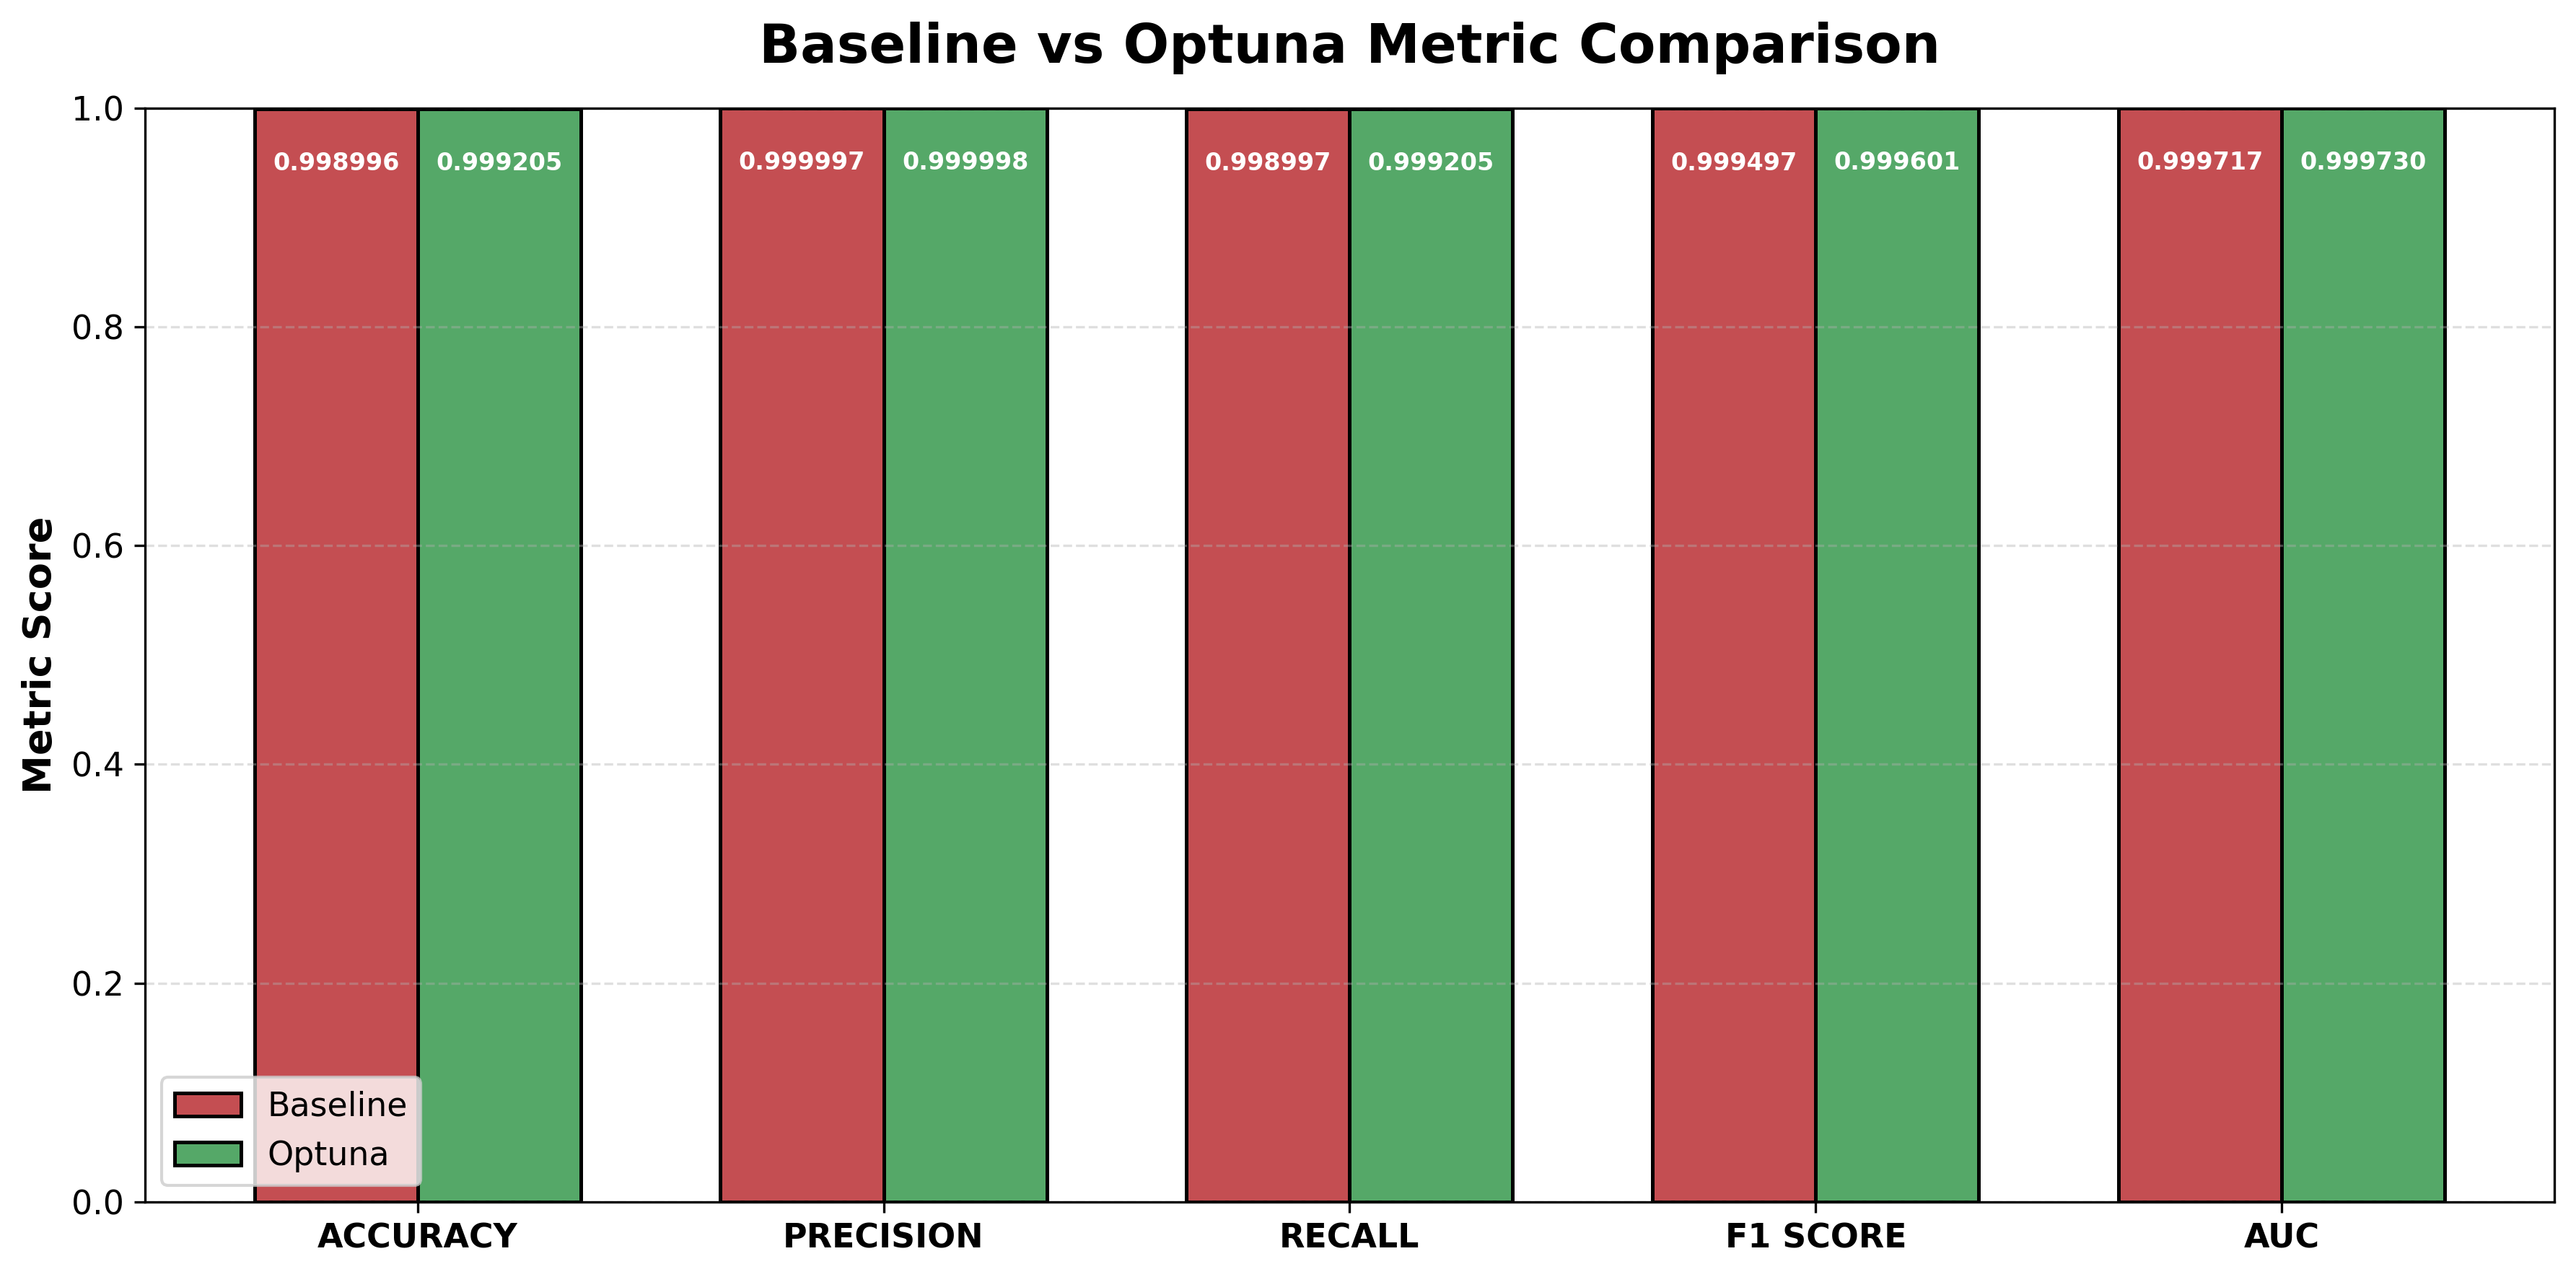

In [31]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# =========================================================
# Metrics
# =========================================================

metrics_to_plot = [
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "auc"
]


# =========================================================
# Prepare Data
# =========================================================

metrics_df = df[
    df["Metric"].isin(metrics_to_plot)
].copy()

metrics_df["Baseline"] = metrics_df["Baseline"].astype(float)
metrics_df["Optuna"] = metrics_df["Optuna"].astype(float)


baseline_values = metrics_df["Baseline"].values
optuna_values = metrics_df["Optuna"].values

metric_labels = [
    metric.replace("_", " ").upper()
    for metric in metrics_df["Metric"]
]


# =========================================================
# Create Figure
# =========================================================

plt.figure(figsize=(12, 6), dpi=300)

x = np.arange(len(metric_labels))
width = 0.35


# =========================================================
# Color Logic
# =========================================================

baseline_colors = []
optuna_colors = []

for b, o in zip(baseline_values, optuna_values):

    if b > o:

        baseline_colors.append("#55A868")   # better -> green
        optuna_colors.append("#C44E52")     # worse -> red

    elif o > b:

        baseline_colors.append("#C44E52")
        optuna_colors.append("#55A868")

    else:

        baseline_colors.append("#55A868")
        optuna_colors.append("#55A868")


# =========================================================
# Create Bars
# =========================================================

bars1 = plt.bar(
    x - width/2,
    baseline_values,
    width,
    label="Baseline",
    color=baseline_colors,
    edgecolor="black",
    linewidth=1.2
)

bars2 = plt.bar(
    x + width/2,
    optuna_values,
    width,
    label="Optuna",
    color=optuna_colors,
    edgecolor="black",
    linewidth=1.2
)


# =========================================================
# Scientific Scaling
# =========================================================

plt.ylim(0.0, 1.0)


# =========================================================
# Labels and Title
# =========================================================

plt.title(
    "Baseline vs Optuna Metric Comparison",
    fontsize=18,
    weight="bold",
    pad=15
)

plt.ylabel(
    "Metric Score",
    fontsize=13,
    weight="bold"
)

plt.xticks(
    x,
    metric_labels,
    fontsize=11,
    weight="bold"
)

plt.yticks(fontsize=11)

plt.legend(
    fontsize=11
)


# =========================================================
# Grid
# =========================================================

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)


# =========================================================
# Labels INSIDE bars
# =========================================================

for bars in [bars1, bars2]:

    for bar in bars:

        yval = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width()/2,
            yval - 0.05,
            f"{yval:.6f}",
            ha="center",
            va="center",
            fontsize=8,
            weight="bold",
            color="white"
        )


# =========================================================
# Tight Layout
# =========================================================

plt.tight_layout()


# =========================================================
# Save Figure
# =========================================================

save_dir = os.path.join("results", "plots")
os.makedirs(save_dir, exist_ok=True)

png_path = os.path.join(
    save_dir,
    "combined_metric_comparison.png"
)

pdf_path = os.path.join(
    save_dir,
    "combined_metric_comparison.pdf"
)

plt.savefig(
    png_path,
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    pdf_path,
    bbox_inches="tight"
)

print(f"Plot saved to:\n- {png_path}\n- {pdf_path}")

plt.show()

## **Conclusion**

The results obtained in this project demonstrate the effectiveness of multi-objective optimization techniques for cybersecurity traffic classification and DDoS detection tasks. By comparing the baseline neural network with the Optuna-optimized architecture, it was observed that the optimized model achieved a better balance between classification performance and computational efficiency.

The Optuna-generated model obtained classification metrics that were comparable to, and in some cases slightly better than, the baseline model. Metrics such as accuracy, precision, recall, F1-score, and AUC remained consistently high, indicating that the optimization process preserved the predictive capability of the neural network while exploring more efficient architectural configurations.

In addition to maintaining strong classification performance, the optimized model significantly reduced inference time. This reduction in prediction latency is particularly important in real-world cybersecurity systems, where rapid response and real-time detection are critical for mitigating Distributed Denial of Service (DDoS) attacks and abnormal network behavior.

The results also highlight the importance of considering multiple objectives during model optimization. Maximizing predictive metrics alone is not always sufficient for practical deployment scenarios. In many applications, especially cybersecurity environments, computational efficiency and response time are equally important factors when selecting a model. Through the use of Pareto-based optimization, Optuna was able to identify architectures that achieve an effective trade-off between performance and inference speed. This demonstrates that automated hyperparameter optimization can produce models that are not only accurate but also more suitable for scalable and real-time systems.

Overall, this project shows that multi-objective optimization using Optuna is a powerful strategy for developing efficient neural network models for cybersecurity applications. The optimized architectures provide a practical balance between high predictive performance and reduced computational cost, making them more appropriate for deployment in real-time intrusion detection environments.